In [38]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [39]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX, LinearAlgebra;

In [104]:
HwannierUp, cell_mapUp = hwannier("wannierUp"), np.loadtxt("wannierUp.map.txt");
HwannierDn, cell_mapDn = hwannier("wannierDn"), np.loadtxt("wannierDn.map.txt");
lattice_vectors = loadlattice("wannier.out");

In [108]:
EsUp, _ = wannier_bands(HwannierUp, cell_mapUp, hcat(bandstructkpoints2q(kpointsfile="../bandstruct.kpoints")...));
EsDn, _ = wannier_bands(HwannierDn, cell_mapDn, hcat(bandstructkpoints2q(kpointsfile="../bandstruct.kpoints")...));

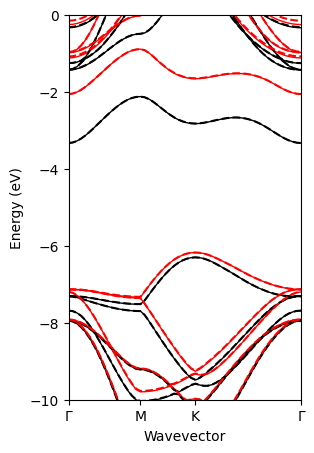

(-10.0, 0.0)

In [109]:
# Saved Wannier data
figure(figsize=(3, 5))
plot_bands("../BN22BC.bands.eigenvals", color_up="black", color_dn="red", kpointsfile = "../bandstruct.kpoints", spin=2, linewidth=1, to_greek=true)
plot(EsUp, linestyle="dashed", color="black")
plot(EsDn, linestyle="dashed", color="red")
ylim(-10, 0)

In [110]:
EnergiesUp, DOSUp = density_of_states(HwannierUp, cell_mapUp, Val(2), histogram_width=100, mesh=20, monte_carlo=true, num_blocks=100)
EnergiesDn, DOSDn = density_of_states(HwannierDn, cell_mapDn, Val(2), histogram_width=100, mesh=20, monte_carlo=true, num_blocks=100)

([-26.155152824703237, -26.145153746545514, -26.135154668387788, -26.125155590230065, -26.115156512072343, -26.10515743391462, -26.095158355756894, -26.08515927759917, -26.07516019944145, -26.065161121283722  …  5.421935997388104, 5.431935075545827, 5.441934153703553, 5.451933231861275, 5.461932310018998, 5.471931388176724, 5.481930466334447, 5.491929544492169, 5.501928622649896, 5.511927700807618], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

In [12]:
np.savetxt("DosUp.txt", hcat(EnergiesUp, DOSUp))
np.savetxt("DosDn.txt", hcat(EnergiesDn, DOSDn))

In [111]:
x, y = find_chemical_potential(EnergiesUp, DOSUp)
x[argmin(abs.(y .- 16.5))]

-2.640839712362954

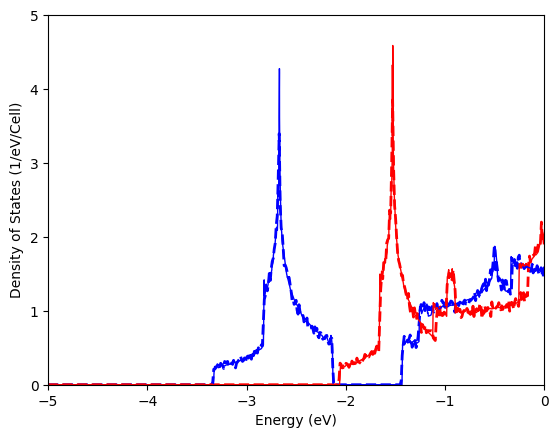

(-5.0, 0.0)

In [115]:
#Checking that the DOS from wannier is correct
plot(EnergiesUp, DOSUp, color="blue", linestyle="dashed", linewidth=2)
plot(EnergiesDn, DOSDn, color="red", linestyle="dashed", linewidth=2)
density_of_states("../DOS/BN22BC.dosUp", "../DOS/BN22BC.dosDn", linewidth=1, color_up="blue", color_dn="red")
ylim(0, 5)
xlim(-5, 0)

In [199]:
epsilons = zeros(100, 100);
kpoints  = bandstructkpoints2q(interpolate=5);
energies = collect(range(0, 100, length=10000));
landau_lower = zeros(50);
landau_upper = zeros(50);

In [200]:
for (i, k) in enumerate(kpoints[1:50])
    i == 1 && continue
    polarizations = parse.(Float64, readlines("Plasmon.out-$i"))
    for (j, ω) in enumerate(range(0.05, 1, length=100))
        epsilons[i, j] = imag(1/ϵ(k, lattice_vectors, ω, energies, polarizations, δ=0.001, normalized=true))
    end
    lower = findfirst(iszero.(polarizations))
    upper = findfirst(.!iszero.(polarizations)[lower:end])+lower-1
    landau_lower[i] = energies[lower]
    landau_upper[i] = energies[upper]
end

In [201]:
plasmon = [range(0.05, 1.5, length=100)[argmax(x)] for x in eachrow(log.(abs.(epsilons[2:50, :])))];
plasmon = [0, plasmon...]
qs, confinements = confinement(lattice_vectors, kpoints[1:50], plasmon)
confinements[1] = 0;
plasmon = smooth(plasmon, win_len=10)
confinements = smooth(confinements, win_len=10);
landau_lower = smooth(landau_lower, win_len=10);
landau_upper = smooth(landau_upper, win_len=10);

In [202]:
landau_lower

50-element Vector{Float64}:
 0.009809997994174369
 0.029502950295029418
 0.04938690470172019
 0.06950695069506946
 0.08981799879425423
 0.11001100110010986
 0.1302040034059656
 0.15089705571682177
 0.17220820382600754
 0.19401940194019388
 0.216021602160216
 0.23783280027440235
 0.25914394838358823
 ⋮
 0.7658856055549301
 0.7831963536241122
 0.7998890058949645
 0.816081608160816
 0.8320832083208318
 0.8480848084808481
 0.864086408640864
 0.88008800880088
 0.8957076047492245
 0.9101360985817328
 0.9230193529184165
 0.9345934593459344

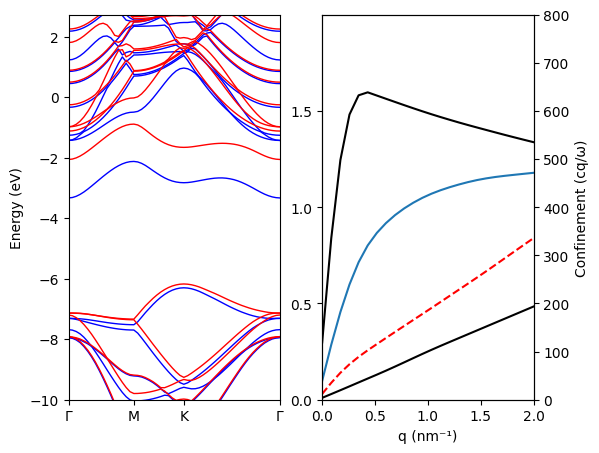

PyObject Text(575.1805555555555, 0.5, 'Confinement (cq/ω)')

In [204]:
figure(figsize=(6, 5))
subplot(1, 2, 1)
plot_bands("../BN22BC.bands.eigenvals", kpointsfile = "../bandstruct.kpoints", spin=2, linewidth=1, whichbands=[1:28...],  to_greek=true)

ylim(-10, 0.1/eV)
xlabel("")
xlim(0, 55)

subplot(1, 2, 2)
plot(qs*10, plasmon)
plot(qs*10, landau_lower, color="black")
plot(qs*10, landau_upper, color="black")

xlabel("q (nm⁻¹)")
ylim(0, 2)
yticks([0, 0.5, 1, 1.5])
twinx()
plot(qs*10, confinements, color="red", linestyle="dashed")
ylim(0, 800)
xlim(0, maximum(qs)*10)
xlim(0, 2)
ylabel("Confinement (cq/ω)")



In [99]:
np.savetxt("Plasmon.txt", hcat(qs, plasmon, confinements))

In [205]:
qs, plasmon, confinements = [x for x in eachcol(np.loadtxt("Plasmon.txt"))];

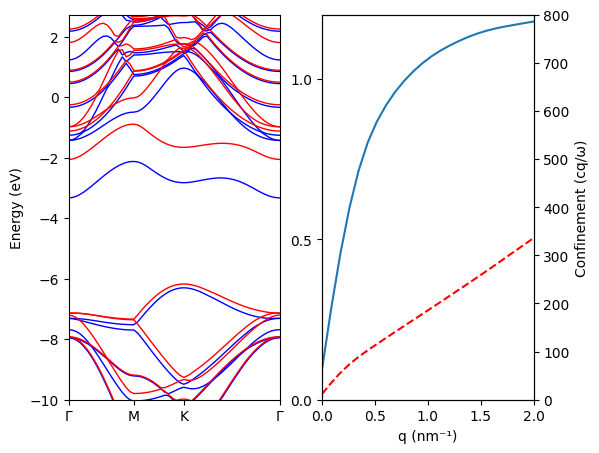

(0.0, 2.0)

In [206]:
figure(figsize=(6, 5))
subplot(1, 2, 1)
plot_bands("../BN22BC.bands.eigenvals", kpointsfile = "../bandstruct.kpoints", spin=2, linewidth=1, whichbands=[1:28...],  to_greek=true)

ylim(-10, 0.1/eV)
xlabel("")
xlim(0, 55)

subplot(1, 2, 2)
plot(qs*10, plasmon)
xlabel("q (nm⁻¹)")
ylim(0, 1.2)
yticks([0, 0.5, 1, 1.5])
ylim(0, 1.2)
twinx()
plot(qs*10, confinements, color="red", linestyle="dashed")
ylim(0, 800)
xlim(0, maximum(qs)*10)
ylabel("Confinement (cq/ω)")
xlim(0, 2)
